In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('4四级.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000
mean,2000.050030,0.163048,5.607178,0.042822,-24.376800,-0.000003,-0.000050,0.000002,4994.70075,4957.142000
std,1154.714989,401.008617,93.005630,2.851035,379.528224,0.000376,0.018356,0.000222,753.57593,277.992156
min,0.100000,-1510.000000,-373.000000,-11.100000,-1390.000000,-0.001810,-0.067500,-0.001290,2290.00000,4120.000000
25%,1000.075015,-278.000000,-56.400000,-1.830000,-285.000000,-0.000251,-0.012900,-0.000136,4480.00000,4750.000000
50%,2000.050030,-5.955000,4.280000,0.030350,-31.600000,-0.000003,0.000474,-0.000001,4980.00000,4950.000000
75%,3000.025045,277.000000,64.700000,1.900000,236.000000,0.000246,0.012600,0.000135,5500.00000,5170.000000
max,4000.000060,1340.000000,452.000000,11.600000,1190.000000,0.001830,0.068400,0.001310,8110.00000,5700.000000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

def Acc(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [7]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
print(force150_x2.shape)
# # 输入100步长输出2步长
# force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
# force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
# print(force1100_x2.shape)


# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
print(force150_x4.shape)
# # 输入100步长输出4步长
# force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
# force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
# print(force1100_x4.shape)



# # 输入50步长输出6步长
# force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
# force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# # 输入100步长输出6步长
# force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)



# # 输入50步长输出8步长
# force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
# force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
# print(force150_x8.shape)
# # 输入100步长输出8步长
# force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
# force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
# print(force1100_x8.shape)

(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)


In [10]:
print(force150_y1)
print(force150_y2)
print(force150_y3)
print(force150_y4)

[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]


In [11]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
print(heave50_x2.shape)
# # 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
print(heave50_x4.shape)
# # 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# # 输入50步长输出6步长
# heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
# heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
# print(heave50_x6.shape)
# # 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# # 输入50步长输出8步长
# heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
# heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
# print(heave50_x8.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# Surge
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
print(surge50_x2.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
print(surge50_x4.shape)
# # 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# # 输入50步长输出6步长
# surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
# surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
# print(surge50_x6.shape)
# # 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# # 输入50步长输出8步长
# surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
# surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
# print(surge50_x8.shape)
# # 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# Pitch
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
print(pitch50_x2.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
print(pitch50_x4.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# # 输入50步长输出6步长
# pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
# pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
# print(pitch50_x6.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# # 输入50步长输出8步长
# pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
# pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
# print(pitch50_x8.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)


### 模型比较

In [12]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y
# # Bi-StatefulLSTM
# def Model_BiSLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, Batch_size=256):
#     model = Sequential() 
#     model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
#     model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
#     model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
#     adam = Adam(lr = lr)
#     model.compile(loss='mse', optimizer='adam')
#     history = model.fit(train_X, train_Y, epochs=epochs, batch_size=Batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
#     model.reset_states()
#     model_structure = model.summary()
#     pre_Y = model.predict(valid_X,batch_size=Batch_size)
#     return model, history, pre_Y

# CNN-BiLSTM-Attention
from keras.layers import Input, Dense, LSTM, merge ,Conv1D, Dropout, Bidirectional, Multiply
from keras.models import Model
from attention_utils import get_activations
from keras.layers import merge
from keras.layers.core import *
from keras.layers.recurrent import LSTM
from keras.models import *
SINGLE_ATTENTION_VECTOR = False
def attention_3d_block(inputs):
    # inputs.shape = (batch_size, time_steps, input_dim)
    input_dim = int(inputs.shape[2])
    a = inputs
    #a = Permute((2, 1))(inputs)
    #a = Reshape((input_dim, TIME_STEPS))(a) # this line is not useful. It's just to know which dimension is what.
    a = Dense(input_dim, activation='softmax')(a)
    if SINGLE_ATTENTION_VECTOR:
        a = Lambda(lambda x: K.mean(x, axis=1), name='dim_reduction')(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((1, 2), name='attention_vec')(a)

    output_attention_mul = merge([inputs, a_probs], name='attention_mul', mode='mul')
    return output_attention_mul

# 注意力机制的另一种写法 适合上述报错使用 来源:https://blog.csdn.net/uhauha2929/article/details/80733255
def attention_3d_block2(inputs, single_attention_vector=False):
    # 如果上一层是LSTM，需要return_sequences=True
    # inputs.shape = (batch_size, time_steps, input_dim)
    time_steps = K.int_shape(inputs)[1]
    input_dim = K.int_shape(inputs)[2]
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='tanh')(a)
    if single_attention_vector:
        a = Lambda(lambda x: K.mean(x, axis=1))(a)
        a = RepeatVector(input_dim)(a)

    a_probs = Permute((2, 1))(a)
    # 乘上了attention权重，但是并没有求和，好像影响不大
    # 如果分类任务，进行Flatten展开就可以了
    # element-wise
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def attention_model(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    inputs = Input(shape=(TIME_STEPS, INPUT_DIMS))

    x = Conv1D(filters = 64, kernel_size = 1, activation = 'tanh')(inputs)  #, padding = 'same'
    x = Dropout(0.1)(x)

    #lstm_out = Bidirectional(LSTM(lstm_units, activation='relu'), name='bilstm')(x)
    #对于GPU可以使用CuDNNLSTM
    lstm_out1 = LSTM(lstm_units, activation='tanh', return_sequences=True)(x)
#     lstm_out1 = LeakyReLU(alpha=0.3)(lstm_out1)
#     lstm_out1 = Dropout(0.3)(lstm_out1)
#     lstm_out2 = Bidirectional(LSTM(lstm_units, return_sequences=True))(lstm_out1)
#     lstm_out3 = LSTM(lstm_units)(lstm_out2)
#     lstm_out1 = Dropout(0.1)(lstm_out1)
    attention_mul = attention_3d_block2(lstm_out1)
    attention_mul = Flatten()(attention_mul)

    output = Dense(1)(attention_mul)
    model = Model(inputs=[inputs], outputs=output)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

#### 系泊缆力联合预测（时间窗500输出；步长10）

In [13]:
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 4200, 7500, 12000)                                                             
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)

In [14]:
INPUT_DIMS = 1
TIME_STEPS = 500
lstm_units = 64
# 未来运动预测模型建立
heave50_model1, heave50_history1, pre_heave50_Y1 = attention_model(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

surge50_model1, surge50_history1, pre_surge50_Y1 = attention_model(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = attention_model(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 30s - loss: 0.0744 - val_loss: 0.0641
Epoch 2/30
 - 31s - loss: 0.0352 - val_loss: 0.0368
Epoch 3/30
 - 31s - loss: 0.0250 - val_loss: 0.0214
Epoch 4/30
 - 31s - loss: 0.0170 - val_loss: 0.0152
Epoch 5/30
 - 31s - loss: 0.0151 - val_loss: 0.0133
Epoch 6/30
 - 32s - loss: 0.0131 - val_loss: 0.0129
Epoch 7/30
 - 32s - loss: 0.0129 - val_loss: 0.0124
Epoch 8/30
 - 32s - loss: 0.0113 - val_loss: 0.0125
Epoch 9/30
 - 32s - loss: 0.0114 - val_loss: 0.0124
Epoch 10/30
 - 33s - loss: 0.0102 - val_loss: 0.0158
Epoch 11/30
 - 33s - loss: 0.0096 - val_loss: 0.0195
Epoch 12/30
 - 33s - loss: 0.0111 - val_loss: 0.0192
Epoch 13/30
 - 33s - loss: 0.0121 - val_loss: 0.0185
Epoch 14/30
 - 32s - loss: 0.0111 - val_loss: 0.0167
Epoch 15/30
 - 32s - loss: 0.0103 - val_loss: 0.0210
Epoch 16/30
 - 33s - loss: 0.0098 - val_loss: 0.0167
Epoch 17/30
 - 32s - loss: 0.0081 - val_loss: 0.0118
Epoch 18/30
 - 33s - loss: 0.0064 - val_loss: 0.0130
Epoch 1

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 28s - loss: 0.0554 - val_loss: 0.0402
Epoch 2/30
 - 29s - loss: 0.0358 - val_loss: 0.0366
Epoch 3/30
 - 30s - loss: 0.0344 - val_loss: 0.0318
Epoch 4/30
 - 30s - loss: 0.0301 - val_loss: 0.0314
Epoch 5/30
 - 31s - loss: 0.0297 - val_loss: 0.0344
Epoch 6/30
 - 31s - loss: 0.0275 - val_loss: 0.0340
Epoch 7/30
 - 31s - loss: 0.0253 - val_loss: 0.0341
Epoch 8/30
 - 32s - loss: 0.0244 - val_loss: 0.0343
Epoch 9/30
 - 31s - loss: 0.0254 - val_loss: 0.0383
Epoch 10/30
 - 31s - loss: 0.0233 - val_loss: 0.0335
Epoch 11/30
 - 32s - loss: 0.0221 - val_loss: 0.0436
Epoch 12/30
 - 32s - loss: 0.0222 - val_loss: 0.0342
Epoch 13/30
 - 32s - loss: 0.0217 - val_loss: 0.0577
Epoch 14/30
 - 32s - loss: 0.0235 - val_loss: 0.0342
Epoch 15/30
 - 33s - loss: 0.0190 - val_loss: 0.0387
Epoch 16/30
 - 32s - loss: 0.0200 - val_loss: 0.0326
Epoch 17/30
 - 32s - loss: 0.0179 - val_loss: 0.0293
Epoch 18/30
 - 32s - loss: 0.0185 - val_loss: 0.0333
Epoch 1

In [15]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [16]:
pre_heave50_Y1 = heave50_model1.predict(valid_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y1 = surge50_model1.predict(valid_surge50_x1)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y1 = pitch50_model1.predict(valid_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y1.shape)
print(pre_surge50_Y1.shape)
print(pre_pitch50_Y1.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [17]:
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [18]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [19]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0129 - val_loss: 0.0329
Epoch 2/1000
 - 0s - loss: 0.0186 - val_loss: 0.0183
Epoch 3/1000
 - 0s - loss: 0.0101 - val_loss: 0.0192
Epoch 4/1000
 - 0s - loss: 0.0072 - val_loss: 0.0188
Epoch 5/1000
 - 0s - loss: 0.0073 - val_loss: 0.0180
Epoch 6/1000
 - 0s - loss: 0.0067 - val_loss: 0.0177
Epoch 7/1000
 - 0s - loss: 0.0067 - val_loss: 0.0178
Epoch 8/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 9/1000
 - 0s - loss: 0.0067 - val_loss: 0.0177
Epoch 10/1000
 - 0s - loss: 0.0069 - val_loss: 0.0177
Epoch 11/1000
 - 0s - loss: 0.0068 - val_loss: 0.0176
Epoch 12/1000
 - 0s - loss: 0.0069 - val_loss: 0.0177
Epoch 13/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 14/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 15/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 16/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 17/1000
 - 0s - loss: 0.0069 - val_loss: 0.0176
Epoch 18/1000
 - 0s - loss: 0.0069 - val_lo

Epoch 152/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 153/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 154/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 155/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 156/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 157/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 158/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 159/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 160/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 161/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 162/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 163/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 164/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 165/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 166/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 167/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 168/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 169/1000
 - 0s - loss: 0.0060 - val_loss: 0.0175
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 302/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 303/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 304/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 305/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 306/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 307/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 308/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 309/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 310/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 311/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 312/1000
 - 0s - loss: 0.0058 - val_loss: 0.0175
Epoch 313/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 314/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 315/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 316/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 317/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 318/1000
 - 0s - loss: 0.0058 - val_loss: 0.0174
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 451/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 452/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 453/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 454/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 455/1000
 - 0s - loss: 0.0059 - val_loss: 0.0172
Epoch 456/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 457/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 458/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 459/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 460/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 461/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 462/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 463/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 464/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 465/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 466/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 467/1000
 - 0s - loss: 0.0058 - val_loss: 0.0172
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 600/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 601/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 602/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 603/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 604/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 605/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 606/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 607/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 608/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 609/1000
 - 0s - loss: 0.0057 - val_loss: 0.0172
Epoch 610/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 611/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 612/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 613/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 614/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 615/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 616/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 749/1000
 - 0s - loss: 0.0056 - val_loss: 0.0171
Epoch 750/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 751/1000
 - 0s - loss: 0.0056 - val_loss: 0.0171
Epoch 752/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 753/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 754/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 755/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 756/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 757/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 758/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 759/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 760/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 761/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 762/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 763/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 764/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 765/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 898/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 899/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 900/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 901/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 902/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 903/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 904/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 905/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 906/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 907/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 908/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 909/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 910/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 911/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 912/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 913/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 914/1000
 - 0s - loss: 0.0056 - val_loss: 0.0172
Epoch 915/

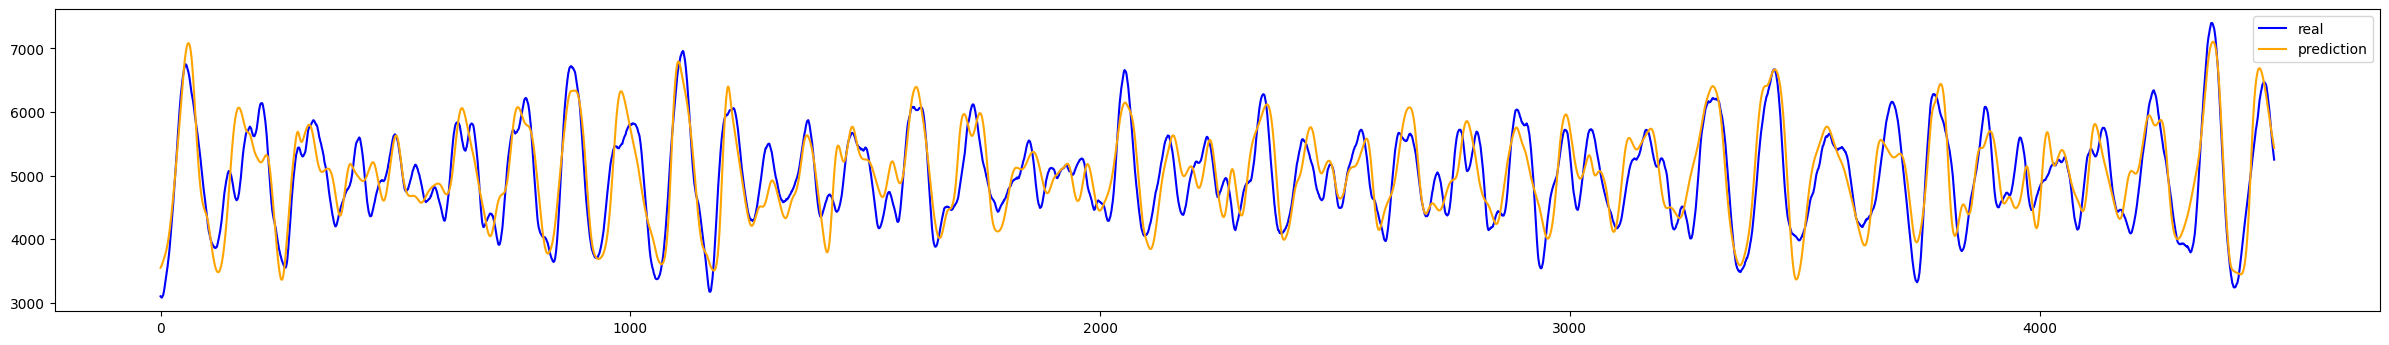

In [20]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force1500_步长10_混合注意力.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [21]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [22]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [23]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0642 - val_loss: 0.0507
Epoch 2/1000
 - 0s - loss: 0.0391 - val_loss: 0.0613
Epoch 3/1000
 - 0s - loss: 0.0298 - val_loss: 0.0408
Epoch 4/1000
 - 0s - loss: 0.0228 - val_loss: 0.0439
Epoch 5/1000
 - 0s - loss: 0.0240 - val_loss: 0.0438
Epoch 6/1000
 - 0s - loss: 0.0230 - val_loss: 0.0431
Epoch 7/1000
 - 0s - loss: 0.0230 - val_loss: 0.0436
Epoch 8/1000
 - 0s - loss: 0.0233 - val_loss: 0.0437
Epoch 9/1000
 - 0s - loss: 0.0229 - val_loss: 0.0434
Epoch 10/1000
 - 0s - loss: 0.0234 - val_loss: 0.0437
Epoch 11/1000
 - 0s - loss: 0.0231 - val_loss: 0.0436
Epoch 12/1000
 - 0s - loss: 0.0233 - val_loss: 0.0436
Epoch 13/1000
 - 0s - loss: 0.0231 - val_loss: 0.0437
Epoch 14/1000
 - 0s - loss: 0.0232 - val_loss: 0.0436
Epoch 15/1000
 - 0s - loss: 0.0231 - val_loss: 0.0437
Epoch 16/1000
 - 0s - loss: 0.0231 - val_loss: 0.0436
Epoch 17/1000
 - 0s - loss: 0.0230 - val_loss: 0.0436
Epoch 18/1000
 - 0s - loss: 0.0230 - val_lo

 - 0s - loss: 0.0207 - val_loss: 0.0430
Epoch 152/1000
 - 0s - loss: 0.0206 - val_loss: 0.0430
Epoch 153/1000
 - 0s - loss: 0.0206 - val_loss: 0.0430
Epoch 154/1000
 - 0s - loss: 0.0206 - val_loss: 0.0429
Epoch 155/1000
 - 0s - loss: 0.0206 - val_loss: 0.0428
Epoch 156/1000
 - 0s - loss: 0.0206 - val_loss: 0.0427
Epoch 157/1000
 - 0s - loss: 0.0206 - val_loss: 0.0425
Epoch 158/1000
 - 0s - loss: 0.0206 - val_loss: 0.0424
Epoch 159/1000
 - 0s - loss: 0.0205 - val_loss: 0.0423
Epoch 160/1000
 - 0s - loss: 0.0205 - val_loss: 0.0423
Epoch 161/1000
 - 0s - loss: 0.0205 - val_loss: 0.0424
Epoch 162/1000
 - 0s - loss: 0.0205 - val_loss: 0.0425
Epoch 163/1000
 - 0s - loss: 0.0205 - val_loss: 0.0426
Epoch 164/1000
 - 0s - loss: 0.0205 - val_loss: 0.0427
Epoch 165/1000
 - 0s - loss: 0.0204 - val_loss: 0.0428
Epoch 166/1000
 - 0s - loss: 0.0204 - val_loss: 0.0429
Epoch 167/1000
 - 0s - loss: 0.0204 - val_loss: 0.0429
Epoch 168/1000
 - 0s - loss: 0.0204 - val_loss: 0.0430
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0177 - val_loss: 0.0413
Epoch 301/1000
 - 0s - loss: 0.0177 - val_loss: 0.0405
Epoch 302/1000
 - 0s - loss: 0.0176 - val_loss: 0.0401
Epoch 303/1000
 - 0s - loss: 0.0174 - val_loss: 0.0402
Epoch 304/1000
 - 0s - loss: 0.0172 - val_loss: 0.0406
Epoch 305/1000
 - 0s - loss: 0.0171 - val_loss: 0.0410
Epoch 306/1000
 - 0s - loss: 0.0172 - val_loss: 0.0412
Epoch 307/1000
 - 0s - loss: 0.0172 - val_loss: 0.0413
Epoch 308/1000
 - 0s - loss: 0.0173 - val_loss: 0.0415
Epoch 309/1000
 - 0s - loss: 0.0173 - val_loss: 0.0417
Epoch 310/1000
 - 0s - loss: 0.0173 - val_loss: 0.0419
Epoch 311/1000
 - 0s - loss: 0.0172 - val_loss: 0.0420
Epoch 312/1000
 - 0s - loss: 0.0172 - val_loss: 0.0421
Epoch 313/1000
 - 0s - loss: 0.0171 - val_loss: 0.0421
Epoch 314/1000
 - 0s - loss: 0.0171 - val_loss: 0.0420
Epoch 315/1000
 - 0s - loss: 0.0171 - val_loss: 0.0418
Epoch 316/1000
 - 0s - loss: 0.0171 - val_loss: 0.0416
Epoch 317/1000
 - 0s - loss: 0.0172 - val_loss: 0.0414
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0162 - val_loss: 0.0411
Epoch 450/1000
 - 0s - loss: 0.0163 - val_loss: 0.0411
Epoch 451/1000
 - 0s - loss: 0.0163 - val_loss: 0.0411
Epoch 452/1000
 - 0s - loss: 0.0163 - val_loss: 0.0412
Epoch 453/1000
 - 0s - loss: 0.0163 - val_loss: 0.0413
Epoch 454/1000
 - 0s - loss: 0.0163 - val_loss: 0.0414
Epoch 455/1000
 - 0s - loss: 0.0163 - val_loss: 0.0416
Epoch 456/1000
 - 0s - loss: 0.0163 - val_loss: 0.0418
Epoch 457/1000
 - 0s - loss: 0.0162 - val_loss: 0.0419
Epoch 458/1000
 - 0s - loss: 0.0162 - val_loss: 0.0419
Epoch 459/1000
 - 0s - loss: 0.0163 - val_loss: 0.0418
Epoch 460/1000
 - 0s - loss: 0.0163 - val_loss: 0.0417
Epoch 461/1000
 - 0s - loss: 0.0164 - val_loss: 0.0414
Epoch 462/1000
 - 0s - loss: 0.0166 - val_loss: 0.0410
Epoch 463/1000
 - 0s - loss: 0.0166 - val_loss: 0.0406
Epoch 464/1000
 - 0s - loss: 0.0165 - val_loss: 0.0404
Epoch 465/1000
 - 0s - loss: 0.0164 - val_loss: 0.0405
Epoch 466/1000
 - 0s - loss: 0.0163 - val_loss: 0.0404
Epoch 467/1000
 - 0s - lo

Epoch 599/1000
 - 0s - loss: 0.0159 - val_loss: 0.0411
Epoch 600/1000
 - 0s - loss: 0.0158 - val_loss: 0.0411
Epoch 601/1000
 - 0s - loss: 0.0158 - val_loss: 0.0411
Epoch 602/1000
 - 0s - loss: 0.0159 - val_loss: 0.0412
Epoch 603/1000
 - 0s - loss: 0.0159 - val_loss: 0.0414
Epoch 604/1000
 - 0s - loss: 0.0159 - val_loss: 0.0416
Epoch 605/1000
 - 0s - loss: 0.0159 - val_loss: 0.0418
Epoch 606/1000
 - 0s - loss: 0.0159 - val_loss: 0.0419
Epoch 607/1000
 - 0s - loss: 0.0158 - val_loss: 0.0419
Epoch 608/1000
 - 0s - loss: 0.0159 - val_loss: 0.0418
Epoch 609/1000
 - 0s - loss: 0.0159 - val_loss: 0.0416
Epoch 610/1000
 - 0s - loss: 0.0159 - val_loss: 0.0414
Epoch 611/1000
 - 0s - loss: 0.0159 - val_loss: 0.0412
Epoch 612/1000
 - 0s - loss: 0.0159 - val_loss: 0.0411
Epoch 613/1000
 - 0s - loss: 0.0158 - val_loss: 0.0410
Epoch 614/1000
 - 0s - loss: 0.0158 - val_loss: 0.0410
Epoch 615/1000
 - 0s - loss: 0.0158 - val_loss: 0.0411
Epoch 616/1000
 - 0s - loss: 0.0159 - val_loss: 0.0412
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0156 - val_loss: 0.0414
Epoch 749/1000
 - 0s - loss: 0.0156 - val_loss: 0.0416
Epoch 750/1000
 - 0s - loss: 0.0156 - val_loss: 0.0416
Epoch 751/1000
 - 0s - loss: 0.0156 - val_loss: 0.0417
Epoch 752/1000
 - 0s - loss: 0.0156 - val_loss: 0.0416
Epoch 753/1000
 - 0s - loss: 0.0156 - val_loss: 0.0415
Epoch 754/1000
 - 0s - loss: 0.0156 - val_loss: 0.0414
Epoch 755/1000
 - 0s - loss: 0.0156 - val_loss: 0.0414
Epoch 756/1000
 - 0s - loss: 0.0156 - val_loss: 0.0413
Epoch 757/1000
 - 0s - loss: 0.0156 - val_loss: 0.0412
Epoch 758/1000
 - 0s - loss: 0.0156 - val_loss: 0.0411
Epoch 759/1000
 - 0s - loss: 0.0156 - val_loss: 0.0411
Epoch 760/1000
 - 0s - loss: 0.0155 - val_loss: 0.0412
Epoch 761/1000
 - 0s - loss: 0.0155 - val_loss: 0.0413
Epoch 762/1000
 - 0s - loss: 0.0155 - val_loss: 0.0414
Epoch 763/1000
 - 0s - loss: 0.0155 - val_loss: 0.0415
Epoch 764/1000
 - 0s - loss: 0.0155 - val_loss: 0.0416
Epoch 765/1000
 - 0s - loss: 0.0155 - val_loss: 0.0416
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 898/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 899/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 900/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 901/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 902/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 903/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 904/1000
 - 0s - loss: 0.0151 - val_loss: 0.0412
Epoch 905/1000
 - 0s - loss: 0.0151 - val_loss: 0.0412
Epoch 906/1000
 - 0s - loss: 0.0151 - val_loss: 0.0412
Epoch 907/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 908/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 909/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 910/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 911/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 912/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 913/1000
 - 0s - loss: 0.0151 - val_loss: 0.0414
Epoch 914/1000
 - 0s - loss: 0.0151 - val_loss: 0.0413
Epoch 915/

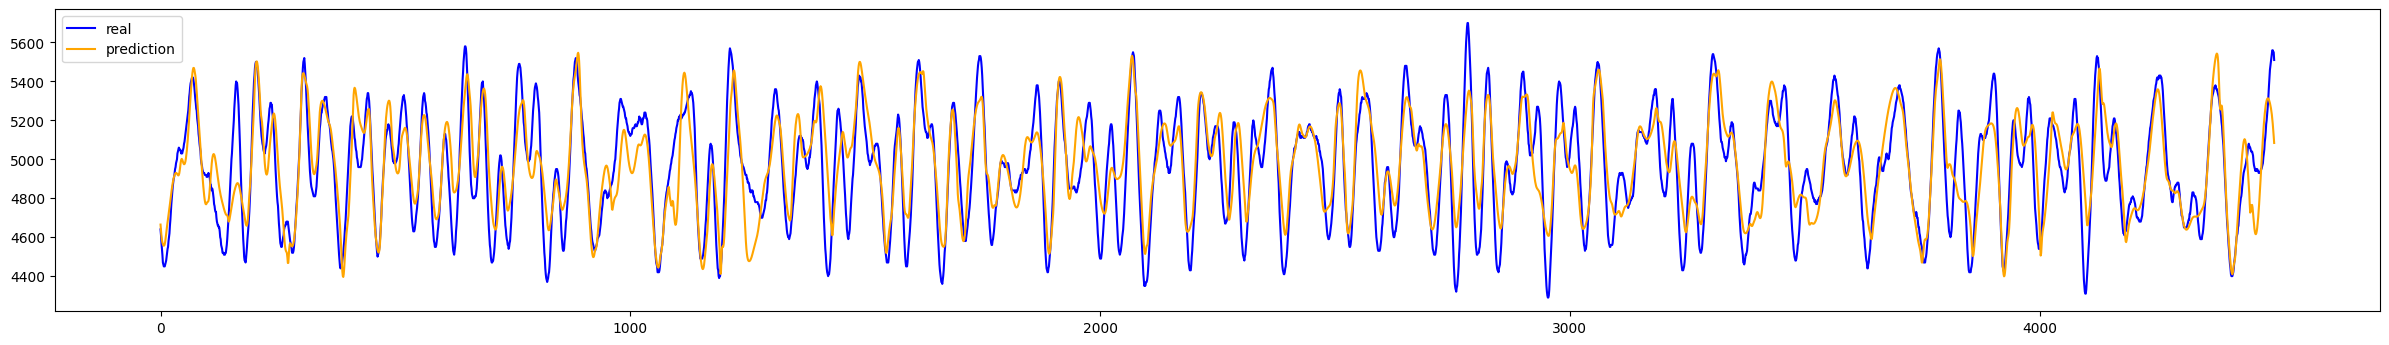

In [24]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_混合注意力.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

In [25]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)

RMSE(sklearn): 0.13135706343818715
Acc: 0.9607732163743891


In [26]:
RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.20367960709818028
Acc: 0.8508808991451767


#### 系泊缆力联合预测（时间窗500输出；步长20）

In [27]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 8000)
heave50_model2, heave50_history2, pre_heave50_Y2 = attention_model(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 8000)
surge50_model2, surge50_history2, pre_surge50_Y2 = attention_model(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 8000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = attention_model(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 24s - loss: 0.0761 - val_loss: 0.0787
Epoch 2/30
 - 24s - loss: 0.0480 - val_loss: 0.0690
Epoch 3/30
 - 24s - loss: 0.0426 - val_loss: 0.0269
Epoch 4/30
 - 24s - loss: 0.0284 - val_loss: 0.0259
Epoch 5/30
 - 24s - loss: 0.0237 - val_loss: 0.0224
Epoch 6/30
 - 24s - loss: 0.0205 - val_loss: 0.0212
Epoch 7/30
 - 24s - loss: 0.0190 - val_loss: 0.0188
Epoch 8/30
 - 25s - loss: 0.0170 - val_loss: 0.0193
Epoch 9/30
 - 24s - loss: 0.0168 - val_loss: 0.0205
Epoch 10/30
 - 24s - loss: 0.0162 - val_loss: 0.0286
Epoch 11/30
 - 24s - loss: 0.0174 - val_loss: 0.0257
Epoch 12/30
 - 24s - loss: 0.0182 - val_loss: 0.0255
Epoch 13/30
 - 25s - loss: 0.0158 - val_loss: 0.0195
Epoch 14/30
 - 24s - loss: 0.0138 - val_loss: 0.0203
Epoch 15/30
 - 24s - loss: 0.0142 - val_loss: 0.0366
Epoch 16/30
 - 25s - loss: 0.0174 - val_loss: 0.0275
Epoch 17/30
 - 25s - loss: 0.0177 - val_loss: 0.0432
Epoch 18/30
 - 25s - loss: 0.0152 - val_loss: 0.0214
Epoch 19

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 34s - loss: 0.0612 - val_loss: 0.0402
Epoch 2/30
 - 34s - loss: 0.0425 - val_loss: 0.0292
Epoch 3/30
 - 34s - loss: 0.0353 - val_loss: 0.0494
Epoch 4/30
 - 34s - loss: 0.0355 - val_loss: 0.0411
Epoch 5/30
 - 34s - loss: 0.0335 - val_loss: 0.0314
Epoch 6/30
 - 34s - loss: 0.0275 - val_loss: 0.0415
Epoch 7/30
 - 34s - loss: 0.0297 - val_loss: 0.0421
Epoch 8/30
 - 35s - loss: 0.0272 - val_loss: 0.0319
Epoch 9/30
 - 35s - loss: 0.0258 - val_loss: 0.0230
Epoch 10/30
 - 35s - loss: 0.0231 - val_loss: 0.0343
Epoch 11/30
 - 35s - loss: 0.0224 - val_loss: 0.0440
Epoch 12/30
 - 36s - loss: 0.0200 - val_loss: 0.0541
Epoch 13/30
 - 36s - loss: 0.0182 - val_loss: 0.0394
Epoch 14/30
 - 36s - loss: 0.0179 - val_loss: 0.0473
Epoch 15/30
 - 35s - loss: 0.0207 - val_loss: 0.0373
Epoch 16/30
 - 35s - loss: 0.0206 - val_loss: 0.0532
Epoch 17/30
 - 36s - loss: 0.0222 - val_loss: 0.0607
Epoch 18/30
 - 35s - loss: 0.0213 - val_loss: 0.1033
Epoch 19

In [28]:
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 12000)
train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 12000)                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 12000)

In [29]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [30]:
pre_heave50_Y2 = heave50_model2.predict(valid_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y2 = surge50_model2.predict(valid_surge50_x2)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y2 = pitch50_model2.predict(valid_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y2.shape)
print(pre_surge50_Y2.shape)
print(pre_pitch50_Y2.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [31]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [32]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 4500, 7500, 12000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [33]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0113 - val_loss: 0.0248
Epoch 2/1000
 - 0s - loss: 0.0076 - val_loss: 0.0199
Epoch 3/1000
 - 0s - loss: 0.0058 - val_loss: 0.0226
Epoch 4/1000
 - 0s - loss: 0.0064 - val_loss: 0.0233
Epoch 5/1000
 - 0s - loss: 0.0110 - val_loss: 0.0183
Epoch 6/1000
 - 0s - loss: 0.0102 - val_loss: 0.0173
Epoch 7/1000
 - 0s - loss: 0.0051 - val_loss: 0.0190
Epoch 8/1000
 - 0s - loss: 0.0051 - val_loss: 0.0187
Epoch 9/1000
 - 0s - loss: 0.0059 - val_loss: 0.0175
Epoch 10/1000
 - 0s - loss: 0.0051 - val_loss: 0.0179
Epoch 11/1000
 - 0s - loss: 0.0051 - val_loss: 0.0183
Epoch 12/1000
 - 0s - loss: 0.0052 - val_loss: 0.0179
Epoch 13/1000
 - 0s - loss: 0.0052 - val_loss: 0.0180
Epoch 14/1000
 - 0s - loss: 0.0052 - val_loss: 0.0180
Epoch 15/1000
 - 0s - loss: 0.0052 - val_loss: 0.0180
Epoch 16/1000
 - 0s - loss: 0.0052 - val_loss: 0.0179
Epoch 17/1000
 - 0s - loss: 0.0052 - val_loss: 0.0180
Epoch 18/1000
 - 0s - loss: 0.0052 - val_lo

 - 0s - loss: 0.0047 - val_loss: 0.0177
Epoch 152/1000
 - 0s - loss: 0.0047 - val_loss: 0.0177
Epoch 153/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 154/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 155/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 156/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 157/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 158/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 159/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 160/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 161/1000
 - 0s - loss: 0.0046 - val_loss: 0.0176
Epoch 162/1000
 - 0s - loss: 0.0046 - val_loss: 0.0176
Epoch 163/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 164/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 165/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 166/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 167/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 168/1000
 - 0s - loss: 0.0046 - val_loss: 0.0175
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 301/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 302/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 303/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 304/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 305/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 306/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 307/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 308/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 309/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 310/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 311/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 312/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 313/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 314/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 315/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 316/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 317/1000
 - 0s - loss: 0.0045 - val_loss: 0.0175
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 450/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 451/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 452/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 453/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 454/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 455/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 456/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 457/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 458/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 459/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 460/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 461/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 462/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 463/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 464/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 465/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 466/1000
 - 0s - loss: 0.0044 - val_loss: 0.0176
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0047 - val_loss: 0.0179
Epoch 599/1000
 - 0s - loss: 0.0048 - val_loss: 0.0179
Epoch 600/1000
 - 0s - loss: 0.0047 - val_loss: 0.0178
Epoch 601/1000
 - 0s - loss: 0.0047 - val_loss: 0.0176
Epoch 602/1000
 - 0s - loss: 0.0046 - val_loss: 0.0177
Epoch 603/1000
 - 0s - loss: 0.0045 - val_loss: 0.0177
Epoch 604/1000
 - 0s - loss: 0.0044 - val_loss: 0.0177
Epoch 605/1000
 - 0s - loss: 0.0044 - val_loss: 0.0177
Epoch 606/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 607/1000
 - 0s - loss: 0.0044 - val_loss: 0.0177
Epoch 608/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 609/1000
 - 0s - loss: 0.0044 - val_loss: 0.0177
Epoch 610/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 611/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 612/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 613/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 614/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 615/1000
 - 0s - loss: 0.0044 - val_loss: 0.0178
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 748/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 749/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 750/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 751/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 752/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 753/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 754/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 755/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 756/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 757/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 758/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 759/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 760/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 761/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 762/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 763/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 764/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 897/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 898/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 899/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 900/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 901/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 902/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 903/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 904/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 905/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 906/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 907/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 908/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 909/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 910/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 911/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 912/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 913/1000
 - 0s - loss: 0.0042 - val_loss: 0.0177
Epoch 914/1000
 - 0s - lo

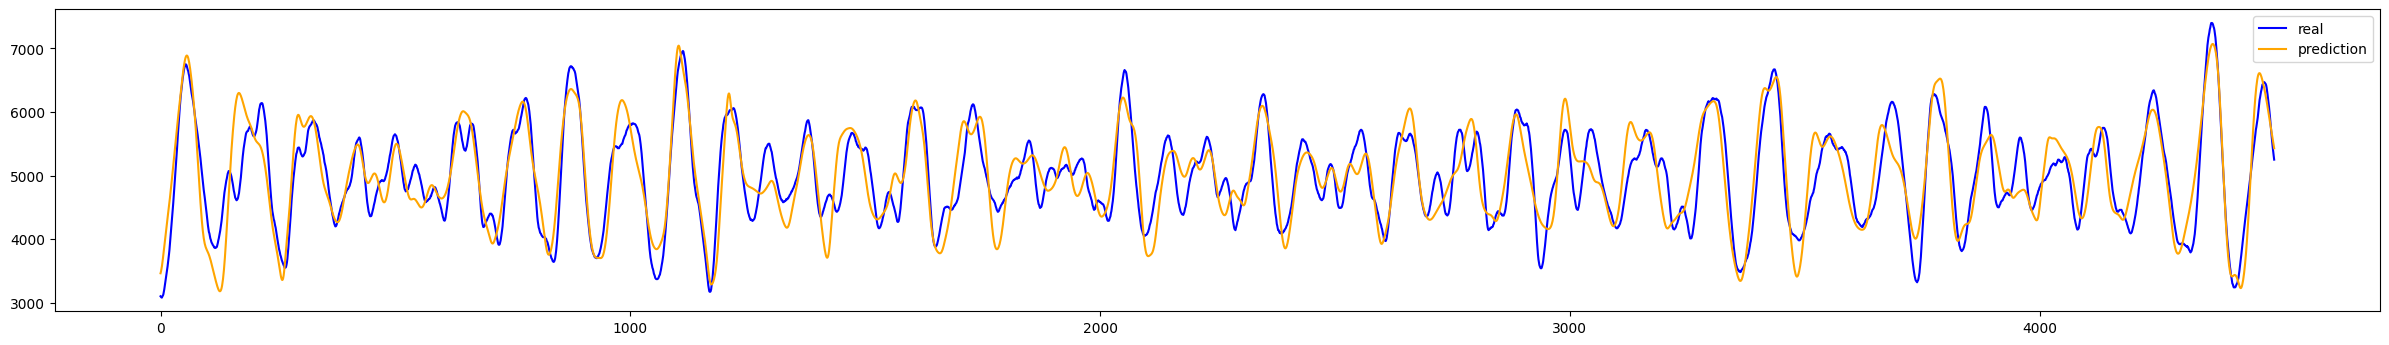

In [34]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force1500_步长20_混合注意力.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [35]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3490:,:], 4, 519)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [36]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 4500, 7500, 12000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [37]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0804 - val_loss: 0.0863
Epoch 2/1000
 - 0s - loss: 0.0475 - val_loss: 0.0881
Epoch 3/1000
 - 0s - loss: 0.0379 - val_loss: 0.0942
Epoch 4/1000
 - 0s - loss: 0.0407 - val_loss: 0.0903
Epoch 5/1000
 - 0s - loss: 0.0372 - val_loss: 0.0900
Epoch 6/1000
 - 0s - loss: 0.0376 - val_loss: 0.0897
Epoch 7/1000
 - 0s - loss: 0.0370 - val_loss: 0.0908
Epoch 8/1000
 - 0s - loss: 0.0377 - val_loss: 0.0899
Epoch 9/1000
 - 0s - loss: 0.0367 - val_loss: 0.0903
Epoch 10/1000
 - 0s - loss: 0.0374 - val_loss: 0.0900
Epoch 11/1000
 - 0s - loss: 0.0367 - val_loss: 0.0903
Epoch 12/1000
 - 0s - loss: 0.0371 - val_loss: 0.0901
Epoch 13/1000
 - 0s - loss: 0.0367 - val_loss: 0.0902
Epoch 14/1000
 - 0s - loss: 0.0369 - val_loss: 0.0902
Epoch 15/1000
 - 0s - loss: 0.0366 - val_loss: 0.0902
Epoch 16/1000
 - 0s - loss: 0.0367 - val_loss: 0.0902
Epoch 17/1000
 - 0s - loss: 0.0365 - val_loss: 0.0903
Epoch 18/1000
 - 0s - loss: 0.0366 - val_lo

 - 0s - loss: 0.0329 - val_loss: 0.0904
Epoch 152/1000
 - 0s - loss: 0.0330 - val_loss: 0.0906
Epoch 153/1000
 - 0s - loss: 0.0329 - val_loss: 0.0909
Epoch 154/1000
 - 0s - loss: 0.0327 - val_loss: 0.0913
Epoch 155/1000
 - 0s - loss: 0.0325 - val_loss: 0.0914
Epoch 156/1000
 - 0s - loss: 0.0325 - val_loss: 0.0912
Epoch 157/1000
 - 0s - loss: 0.0326 - val_loss: 0.0909
Epoch 158/1000
 - 0s - loss: 0.0326 - val_loss: 0.0907
Epoch 159/1000
 - 0s - loss: 0.0326 - val_loss: 0.0906
Epoch 160/1000
 - 0s - loss: 0.0327 - val_loss: 0.0906
Epoch 161/1000
 - 0s - loss: 0.0327 - val_loss: 0.0907
Epoch 162/1000
 - 0s - loss: 0.0326 - val_loss: 0.0909
Epoch 163/1000
 - 0s - loss: 0.0325 - val_loss: 0.0910
Epoch 164/1000
 - 0s - loss: 0.0324 - val_loss: 0.0911
Epoch 165/1000
 - 0s - loss: 0.0324 - val_loss: 0.0910
Epoch 166/1000
 - 0s - loss: 0.0324 - val_loss: 0.0908
Epoch 167/1000
 - 0s - loss: 0.0324 - val_loss: 0.0907
Epoch 168/1000
 - 0s - loss: 0.0325 - val_loss: 0.0906
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0302 - val_loss: 0.0914
Epoch 301/1000
 - 0s - loss: 0.0302 - val_loss: 0.0915
Epoch 302/1000
 - 0s - loss: 0.0301 - val_loss: 0.0915
Epoch 303/1000
 - 0s - loss: 0.0301 - val_loss: 0.0916
Epoch 304/1000
 - 0s - loss: 0.0301 - val_loss: 0.0916
Epoch 305/1000
 - 0s - loss: 0.0300 - val_loss: 0.0917
Epoch 306/1000
 - 0s - loss: 0.0300 - val_loss: 0.0917
Epoch 307/1000
 - 0s - loss: 0.0300 - val_loss: 0.0918
Epoch 308/1000
 - 0s - loss: 0.0300 - val_loss: 0.0918
Epoch 309/1000
 - 0s - loss: 0.0299 - val_loss: 0.0919
Epoch 310/1000
 - 0s - loss: 0.0299 - val_loss: 0.0919
Epoch 311/1000
 - 0s - loss: 0.0299 - val_loss: 0.0920
Epoch 312/1000
 - 0s - loss: 0.0298 - val_loss: 0.0920
Epoch 313/1000
 - 0s - loss: 0.0298 - val_loss: 0.0921
Epoch 314/1000
 - 0s - loss: 0.0298 - val_loss: 0.0921
Epoch 315/1000
 - 0s - loss: 0.0297 - val_loss: 0.0922
Epoch 316/1000
 - 0s - loss: 0.0297 - val_loss: 0.0922
Epoch 317/1000
 - 0s - loss: 0.0297 - val_loss: 0.0923
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0283 - val_loss: 0.0942
Epoch 450/1000
 - 0s - loss: 0.0283 - val_loss: 0.0942
Epoch 451/1000
 - 0s - loss: 0.0283 - val_loss: 0.0942
Epoch 452/1000
 - 0s - loss: 0.0283 - val_loss: 0.0942
Epoch 453/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 454/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 455/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 456/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 457/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 458/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 459/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 460/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 461/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 462/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 463/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 464/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 465/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 466/1000
 - 0s - loss: 0.0282 - val_loss: 0.0942
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 599/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 600/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 601/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 602/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 603/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 604/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 605/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 606/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 607/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 608/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 609/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 610/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 611/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 612/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 613/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 614/1000
 - 0s - loss: 0.0273 - val_loss: 0.0941
Epoch 615/1000
 - 0s - loss: 0.0273 - val_loss: 0.0940
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0267 - val_loss: 0.0940
Epoch 748/1000
 - 0s - loss: 0.0266 - val_loss: 0.0941
Epoch 749/1000
 - 0s - loss: 0.0267 - val_loss: 0.0940
Epoch 750/1000
 - 0s - loss: 0.0267 - val_loss: 0.0941
Epoch 751/1000
 - 0s - loss: 0.0267 - val_loss: 0.0940
Epoch 752/1000
 - 0s - loss: 0.0266 - val_loss: 0.0941
Epoch 753/1000
 - 0s - loss: 0.0266 - val_loss: 0.0941
Epoch 754/1000
 - 0s - loss: 0.0266 - val_loss: 0.0941
Epoch 755/1000
 - 0s - loss: 0.0266 - val_loss: 0.0941
Epoch 756/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 757/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 758/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 759/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 760/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 761/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 762/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 763/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 764/1000
 - 0s - loss: 0.0265 - val_loss: 0.0941
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0255 - val_loss: 0.0963
Epoch 897/1000
 - 0s - loss: 0.0254 - val_loss: 0.0962
Epoch 898/1000
 - 0s - loss: 0.0254 - val_loss: 0.0963
Epoch 899/1000
 - 0s - loss: 0.0254 - val_loss: 0.0963
Epoch 900/1000
 - 0s - loss: 0.0253 - val_loss: 0.0964
Epoch 901/1000
 - 0s - loss: 0.0253 - val_loss: 0.0964
Epoch 902/1000
 - 0s - loss: 0.0253 - val_loss: 0.0964
Epoch 903/1000
 - 0s - loss: 0.0253 - val_loss: 0.0965
Epoch 904/1000
 - 0s - loss: 0.0253 - val_loss: 0.0965
Epoch 905/1000
 - 0s - loss: 0.0253 - val_loss: 0.0965
Epoch 906/1000
 - 0s - loss: 0.0253 - val_loss: 0.0965
Epoch 907/1000
 - 0s - loss: 0.0253 - val_loss: 0.0966
Epoch 908/1000
 - 0s - loss: 0.0253 - val_loss: 0.0966
Epoch 909/1000
 - 0s - loss: 0.0252 - val_loss: 0.0966
Epoch 910/1000
 - 0s - loss: 0.0252 - val_loss: 0.0967
Epoch 911/1000
 - 0s - loss: 0.0252 - val_loss: 0.0967
Epoch 912/1000
 - 0s - loss: 0.0252 - val_loss: 0.0967
Epoch 913/1000
 - 0s - loss: 0.0252 - val_loss: 0.0967
Epoch 914/1000
 - 0s - lo

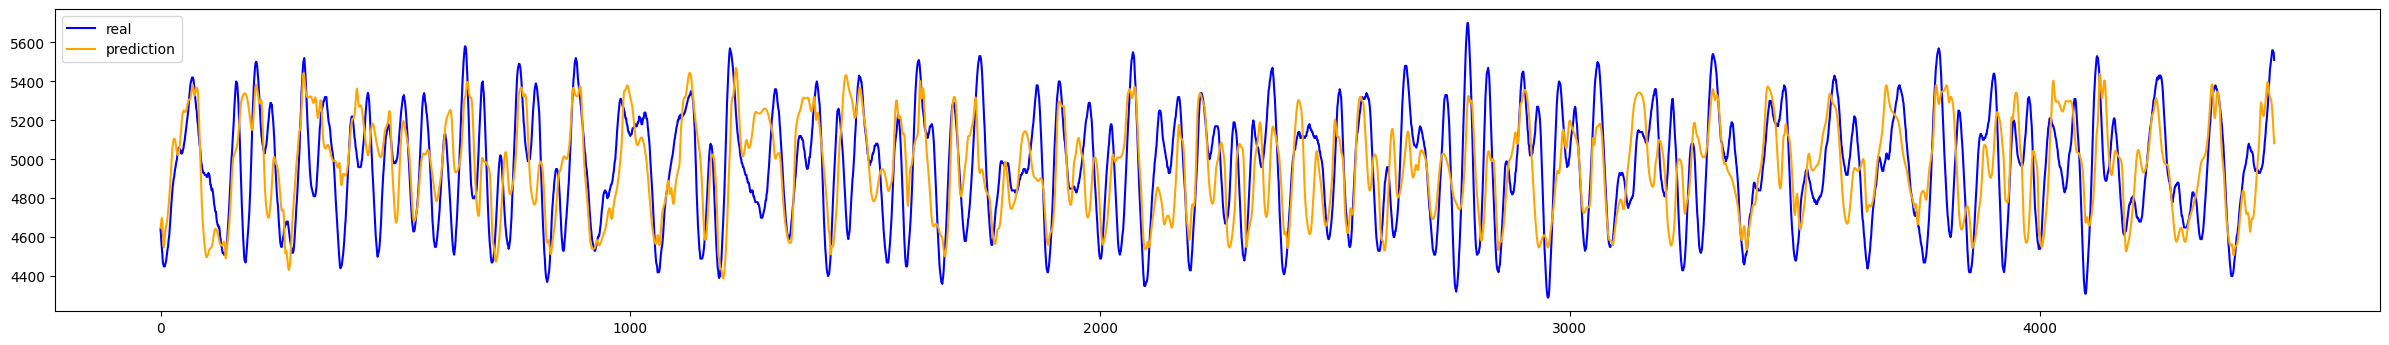

In [38]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force2500_步长20_混合注意力.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

In [39]:
RNSE(valid50_y2_Force1,N_pre50_Y2_Force1)
Acc(valid50_y2_Force1,N_pre50_Y2_Force1)

RMSE(sklearn): 0.13282481748390468
Acc: 0.987005693111348


In [40]:
RNSE(valid50_y2_Force2,N_pre50_Y2_Force2)
Acc(valid50_y2_Force2,N_pre50_Y2_Force2)

RMSE(sklearn): 0.3142541335519012
Acc: 0.8579763143030512


#### 系泊缆力联合预测（时间窗500输出；步长30）

In [41]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 8000)
heave50_model3, heave50_history3, pre_heave50_Y3 = attention_model(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 8000)
surge50_model3, surge50_history3, pre_surge50_Y3 = attention_model(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 8000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = attention_model(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 34s - loss: 0.0836 - val_loss: 0.0771
Epoch 2/30
 - 34s - loss: 0.0509 - val_loss: 0.0277
Epoch 3/30
 - 34s - loss: 0.0288 - val_loss: 0.0272
Epoch 4/30
 - 34s - loss: 0.0261 - val_loss: 0.0213
Epoch 5/30
 - 34s - loss: 0.0206 - val_loss: 0.0186
Epoch 6/30
 - 34s - loss: 0.0211 - val_loss: 0.0197
Epoch 7/30
 - 34s - loss: 0.0204 - val_loss: 0.0218
Epoch 8/30
 - 34s - loss: 0.0178 - val_loss: 0.0219
Epoch 9/30
 - 34s - loss: 0.0183 - val_loss: 0.0253
Epoch 10/30
 - 34s - loss: 0.0168 - val_loss: 0.0194
Epoch 11/30
 - 34s - loss: 0.0192 - val_loss: 0.0268
Epoch 12/30
 - 35s - loss: 0.0154 - val_loss: 0.0319
Epoch 13/30
 - 34s - loss: 0.0203 - val_loss: 0.0351
Epoch 14/30
 - 34s - loss: 0.0131 - val_loss: 0.0244
Epoch 15/30
 - 34s - loss: 0.0162 - val_loss: 0.0333
Epoch 16/30
 - 34s - loss: 0.0160 - val_loss: 0.0217
Epoch 17/30
 - 35s - loss: 0.0113 - val_loss: 0.0512
Epoch 18/30
 - 35s - loss: 0.0115 - val_loss: 0.0363
Epoch 19

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 35s - loss: 0.0703 - val_loss: 0.0561
Epoch 2/30
 - 36s - loss: 0.0636 - val_loss: 0.0533
Epoch 3/30
 - 36s - loss: 0.0574 - val_loss: 0.0419
Epoch 4/30
 - 36s - loss: 0.0496 - val_loss: 0.0404
Epoch 5/30
 - 36s - loss: 0.0507 - val_loss: 0.0397
Epoch 6/30
 - 36s - loss: 0.0460 - val_loss: 0.0375
Epoch 7/30
 - 36s - loss: 0.0430 - val_loss: 0.0402
Epoch 8/30
 - 36s - loss: 0.0424 - val_loss: 0.0423
Epoch 9/30
 - 36s - loss: 0.0409 - val_loss: 0.0379
Epoch 10/30
 - 36s - loss: 0.0382 - val_loss: 0.0423
Epoch 11/30
 - 36s - loss: 0.0387 - val_loss: 0.0465
Epoch 12/30
 - 36s - loss: 0.0364 - val_loss: 0.0683
Epoch 13/30
 - 36s - loss: 0.0361 - val_loss: 0.1739
Epoch 14/30
 - 36s - loss: 0.0437 - val_loss: 0.0963
Epoch 15/30
 - 36s - loss: 0.0349 - val_loss: 0.0770
Epoch 16/30
 - 37s - loss: 0.0316 - val_loss: 0.0821
Epoch 17/30
 - 36s - loss: 0.0349 - val_loss: 0.0513
Epoch 18/30
 - 36s - loss: 0.0266 - val_loss: 0.0826
Epoch 19

In [42]:
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 12000)
train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 12000)                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 12000)

In [43]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [44]:
pre_heave50_Y3 = heave50_model3.predict(valid_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y3 = surge50_model3.predict(valid_surge50_x3)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y3 = pitch50_model3.predict(valid_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
# print(pre_heave50_Y3.shape)
# print(pre_surge50_Y3.shape)
# print(pre_pitch50_Y3.shape)

In [45]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [46]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 4500, 7500, 12000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [47]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0236 - val_loss: 0.0179
Epoch 2/1000
 - 0s - loss: 0.0089 - val_loss: 0.0192
Epoch 3/1000
 - 0s - loss: 0.0077 - val_loss: 0.0201
Epoch 4/1000
 - 0s - loss: 0.0077 - val_loss: 0.0183
Epoch 5/1000
 - 0s - loss: 0.0067 - val_loss: 0.0198
Epoch 6/1000
 - 0s - loss: 0.0068 - val_loss: 0.0183
Epoch 7/1000
 - 0s - loss: 0.0067 - val_loss: 0.0191
Epoch 8/1000
 - 0s - loss: 0.0066 - val_loss: 0.0187
Epoch 9/1000
 - 0s - loss: 0.0068 - val_loss: 0.0187
Epoch 10/1000
 - 0s - loss: 0.0067 - val_loss: 0.0188
Epoch 11/1000
 - 0s - loss: 0.0068 - val_loss: 0.0187
Epoch 12/1000
 - 0s - loss: 0.0067 - val_loss: 0.0187
Epoch 13/1000
 - 0s - loss: 0.0068 - val_loss: 0.0187
Epoch 14/1000
 - 0s - loss: 0.0068 - val_loss: 0.0187
Epoch 15/1000
 - 0s - loss: 0.0067 - val_loss: 0.0187
Epoch 16/1000
 - 0s - loss: 0.0067 - val_loss: 0.0187
Epoch 17/1000
 - 0s - loss: 0.0067 - val_loss: 0.0187
Epoch 18/1000
 - 0s - loss: 0.0067 - val_lo

Epoch 152/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 153/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 154/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 155/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 156/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 157/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 158/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 159/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 160/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 161/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 162/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 163/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 164/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 165/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 166/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 167/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 168/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 169/1000
 - 0s - loss: 0.0062 - val_loss: 0.0192
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0060 - val_loss: 0.0193
Epoch 302/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 303/1000
 - 0s - loss: 0.0060 - val_loss: 0.0193
Epoch 304/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 305/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 306/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 307/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 308/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 309/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 310/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 311/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 312/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 313/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 314/1000
 - 0s - loss: 0.0061 - val_loss: 0.0193
Epoch 315/1000
 - 0s - loss: 0.0061 - val_loss: 0.0193
Epoch 316/1000
 - 0s - loss: 0.0061 - val_loss: 0.0193
Epoch 317/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 318/1000
 - 0s - loss: 0.0060 - val_loss: 0.0194
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0097 - val_loss: 0.0204
Epoch 451/1000
 - 0s - loss: 0.0092 - val_loss: 0.0186
Epoch 452/1000
 - 0s - loss: 0.0066 - val_loss: 0.0201
Epoch 453/1000
 - 0s - loss: 0.0063 - val_loss: 0.0192
Epoch 454/1000
 - 0s - loss: 0.0061 - val_loss: 0.0191
Epoch 455/1000
 - 0s - loss: 0.0058 - val_loss: 0.0197
Epoch 456/1000
 - 0s - loss: 0.0059 - val_loss: 0.0194
Epoch 457/1000
 - 0s - loss: 0.0058 - val_loss: 0.0196
Epoch 458/1000
 - 0s - loss: 0.0058 - val_loss: 0.0196
Epoch 459/1000
 - 0s - loss: 0.0057 - val_loss: 0.0196
Epoch 460/1000
 - 0s - loss: 0.0057 - val_loss: 0.0196
Epoch 461/1000
 - 0s - loss: 0.0057 - val_loss: 0.0196
Epoch 462/1000
 - 0s - loss: 0.0057 - val_loss: 0.0196
Epoch 463/1000
 - 0s - loss: 0.0057 - val_loss: 0.0197
Epoch 464/1000
 - 0s - loss: 0.0057 - val_loss: 0.0197
Epoch 465/1000
 - 0s - loss: 0.0057 - val_loss: 0.0197
Epoch 466/1000
 - 0s - loss: 0.0057 - val_loss: 0.0197
Epoch 467/1000
 - 0s - loss: 0.0057 - val_loss: 0.0197
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0055 - val_loss: 0.0199
Epoch 600/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 601/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 602/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 603/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 604/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 605/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 606/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 607/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 608/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 609/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 610/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 611/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 612/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 613/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 614/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 615/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 616/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 749/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 750/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 751/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 752/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 753/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 754/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 755/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 756/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 757/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 758/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 759/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 760/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 761/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 762/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 763/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 764/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 765/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 898/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 899/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 900/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 901/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 902/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 903/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 904/1000
 - 0s - loss: 0.0055 - val_loss: 0.0201
Epoch 905/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 906/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 907/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 908/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 909/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 910/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 911/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 912/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 913/1000
 - 0s - loss: 0.0055 - val_loss: 0.0202
Epoch 914/1000
 - 0s - loss: 0.0055 - val_loss: 0.0200
Epoch 915/

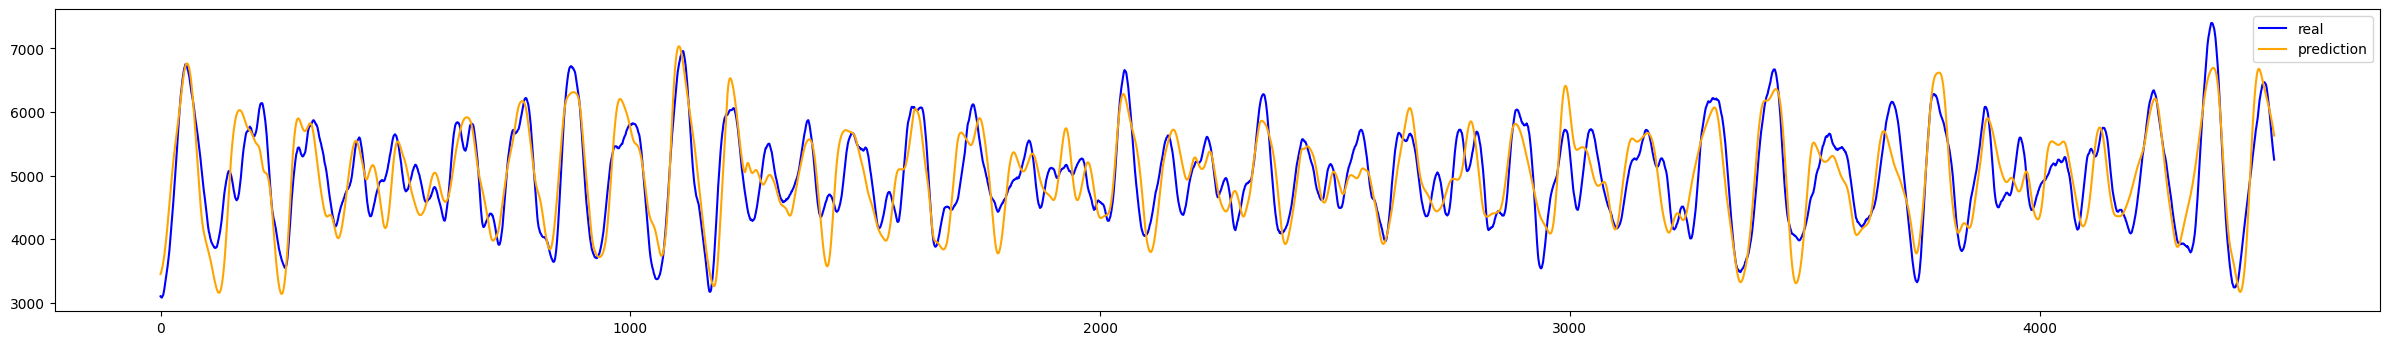

In [48]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force1500_步长30_混合注意力.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [49]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3480:,:], 4, 529)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [50]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 4500, 7500, 12000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [51]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0744 - val_loss: 0.1219
Epoch 2/1000
 - 0s - loss: 0.0404 - val_loss: 0.1179
Epoch 3/1000
 - 0s - loss: 0.0342 - val_loss: 0.1271
Epoch 4/1000
 - 0s - loss: 0.0365 - val_loss: 0.1205
Epoch 5/1000
 - 0s - loss: 0.0343 - val_loss: 0.1224
Epoch 6/1000
 - 0s - loss: 0.0348 - val_loss: 0.1212
Epoch 7/1000
 - 0s - loss: 0.0347 - val_loss: 0.1221
Epoch 8/1000
 - 0s - loss: 0.0347 - val_loss: 0.1218
Epoch 9/1000
 - 0s - loss: 0.0346 - val_loss: 0.1217
Epoch 10/1000
 - 0s - loss: 0.0346 - val_loss: 0.1218
Epoch 11/1000
 - 0s - loss: 0.0345 - val_loss: 0.1218
Epoch 12/1000
 - 0s - loss: 0.0344 - val_loss: 0.1219
Epoch 13/1000
 - 0s - loss: 0.0344 - val_loss: 0.1219
Epoch 14/1000
 - 0s - loss: 0.0343 - val_loss: 0.1219
Epoch 15/1000
 - 0s - loss: 0.0343 - val_loss: 0.1219
Epoch 16/1000
 - 0s - loss: 0.0342 - val_loss: 0.1219
Epoch 17/1000
 - 0s - loss: 0.0342 - val_loss: 0.1220
Epoch 18/1000
 - 0s - loss: 0.0341 - val_lo

 - 0s - loss: 0.0312 - val_loss: 0.1284
Epoch 152/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 153/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 154/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 155/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 156/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 157/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 158/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 159/1000
 - 0s - loss: 0.0311 - val_loss: 0.1284
Epoch 160/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 161/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 162/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 163/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 164/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 165/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 166/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 167/1000
 - 0s - loss: 0.0310 - val_loss: 0.1284
Epoch 168/1000
 - 0s - loss: 0.0310 - val_loss: 0.1283
Epoch 169/1000
 - 0s - lo

Epoch 301/1000
 - 0s - loss: 0.0282 - val_loss: 0.1292
Epoch 302/1000
 - 0s - loss: 0.0281 - val_loss: 0.1289
Epoch 303/1000
 - 0s - loss: 0.0281 - val_loss: 0.1287
Epoch 304/1000
 - 0s - loss: 0.0280 - val_loss: 0.1286
Epoch 305/1000
 - 0s - loss: 0.0280 - val_loss: 0.1288
Epoch 306/1000
 - 0s - loss: 0.0280 - val_loss: 0.1289
Epoch 307/1000
 - 0s - loss: 0.0280 - val_loss: 0.1287
Epoch 308/1000
 - 0s - loss: 0.0279 - val_loss: 0.1285
Epoch 309/1000
 - 0s - loss: 0.0279 - val_loss: 0.1285
Epoch 310/1000
 - 0s - loss: 0.0279 - val_loss: 0.1287
Epoch 311/1000
 - 0s - loss: 0.0278 - val_loss: 0.1287
Epoch 312/1000
 - 0s - loss: 0.0278 - val_loss: 0.1286
Epoch 313/1000
 - 0s - loss: 0.0278 - val_loss: 0.1283
Epoch 314/1000
 - 0s - loss: 0.0277 - val_loss: 0.1283
Epoch 315/1000
 - 0s - loss: 0.0277 - val_loss: 0.1285
Epoch 316/1000
 - 0s - loss: 0.0277 - val_loss: 0.1286
Epoch 317/1000
 - 0s - loss: 0.0277 - val_loss: 0.1285
Epoch 318/1000
 - 0s - loss: 0.0277 - val_loss: 0.1282
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0263 - val_loss: 0.1294
Epoch 451/1000
 - 0s - loss: 0.0265 - val_loss: 0.1296
Epoch 452/1000
 - 0s - loss: 0.0266 - val_loss: 0.1299
Epoch 453/1000
 - 0s - loss: 0.0265 - val_loss: 0.1299
Epoch 454/1000
 - 0s - loss: 0.0266 - val_loss: 0.1294
Epoch 455/1000
 - 0s - loss: 0.0266 - val_loss: 0.1288
Epoch 456/1000
 - 0s - loss: 0.0264 - val_loss: 0.1288
Epoch 457/1000
 - 0s - loss: 0.0263 - val_loss: 0.1292
Epoch 458/1000
 - 0s - loss: 0.0264 - val_loss: 0.1295
Epoch 459/1000
 - 0s - loss: 0.0265 - val_loss: 0.1297
Epoch 460/1000
 - 0s - loss: 0.0265 - val_loss: 0.1299
Epoch 461/1000
 - 0s - loss: 0.0265 - val_loss: 0.1295
Epoch 462/1000
 - 0s - loss: 0.0266 - val_loss: 0.1288
Epoch 463/1000
 - 0s - loss: 0.0264 - val_loss: 0.1287
Epoch 464/1000
 - 0s - loss: 0.0262 - val_loss: 0.1290
Epoch 465/1000
 - 0s - loss: 0.0262 - val_loss: 0.1293
Epoch 466/1000
 - 0s - loss: 0.0263 - val_loss: 0.1296
Epoch 467/1000
 - 0s - loss: 0.0264 - val_loss: 0.1298
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 600/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 601/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 602/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 603/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 604/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 605/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 606/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 607/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 608/1000
 - 0s - loss: 0.0251 - val_loss: 0.1295
Epoch 609/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 610/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 611/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 612/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 613/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 614/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 615/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 616/1000
 - 0s - loss: 0.0250 - val_loss: 0.1295
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0243 - val_loss: 0.1297
Epoch 749/1000
 - 0s - loss: 0.0243 - val_loss: 0.1296
Epoch 750/1000
 - 0s - loss: 0.0243 - val_loss: 0.1297
Epoch 751/1000
 - 0s - loss: 0.0243 - val_loss: 0.1296
Epoch 752/1000
 - 0s - loss: 0.0243 - val_loss: 0.1297
Epoch 753/1000
 - 0s - loss: 0.0244 - val_loss: 0.1297
Epoch 754/1000
 - 0s - loss: 0.0244 - val_loss: 0.1296
Epoch 755/1000
 - 0s - loss: 0.0244 - val_loss: 0.1298
Epoch 756/1000
 - 0s - loss: 0.0244 - val_loss: 0.1296
Epoch 757/1000
 - 0s - loss: 0.0243 - val_loss: 0.1299
Epoch 758/1000
 - 0s - loss: 0.0243 - val_loss: 0.1297
Epoch 759/1000
 - 0s - loss: 0.0242 - val_loss: 0.1299
Epoch 760/1000
 - 0s - loss: 0.0242 - val_loss: 0.1299
Epoch 761/1000
 - 0s - loss: 0.0242 - val_loss: 0.1299
Epoch 762/1000
 - 0s - loss: 0.0242 - val_loss: 0.1299
Epoch 763/1000
 - 0s - loss: 0.0242 - val_loss: 0.1300
Epoch 764/1000
 - 0s - loss: 0.0242 - val_loss: 0.1300
Epoch 765/1000
 - 0s - loss: 0.0242 - val_loss: 0.1300
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0233 - val_loss: 0.1319
Epoch 898/1000
 - 0s - loss: 0.0233 - val_loss: 0.1319
Epoch 899/1000
 - 0s - loss: 0.0233 - val_loss: 0.1320
Epoch 900/1000
 - 0s - loss: 0.0233 - val_loss: 0.1319
Epoch 901/1000
 - 0s - loss: 0.0233 - val_loss: 0.1319
Epoch 902/1000
 - 0s - loss: 0.0234 - val_loss: 0.1318
Epoch 903/1000
 - 0s - loss: 0.0234 - val_loss: 0.1317
Epoch 904/1000
 - 0s - loss: 0.0233 - val_loss: 0.1319
Epoch 905/1000
 - 0s - loss: 0.0233 - val_loss: 0.1317
Epoch 906/1000
 - 0s - loss: 0.0232 - val_loss: 0.1319
Epoch 907/1000
 - 0s - loss: 0.0232 - val_loss: 0.1321
Epoch 908/1000
 - 0s - loss: 0.0231 - val_loss: 0.1321
Epoch 909/1000
 - 0s - loss: 0.0231 - val_loss: 0.1322
Epoch 910/1000
 - 0s - loss: 0.0231 - val_loss: 0.1322
Epoch 911/1000
 - 0s - loss: 0.0231 - val_loss: 0.1321
Epoch 912/1000
 - 0s - loss: 0.0231 - val_loss: 0.1321
Epoch 913/1000
 - 0s - loss: 0.0231 - val_loss: 0.1322
Epoch 914/1000
 - 0s - loss: 0.0231 - val_loss: 0.1321
Epoch 915/

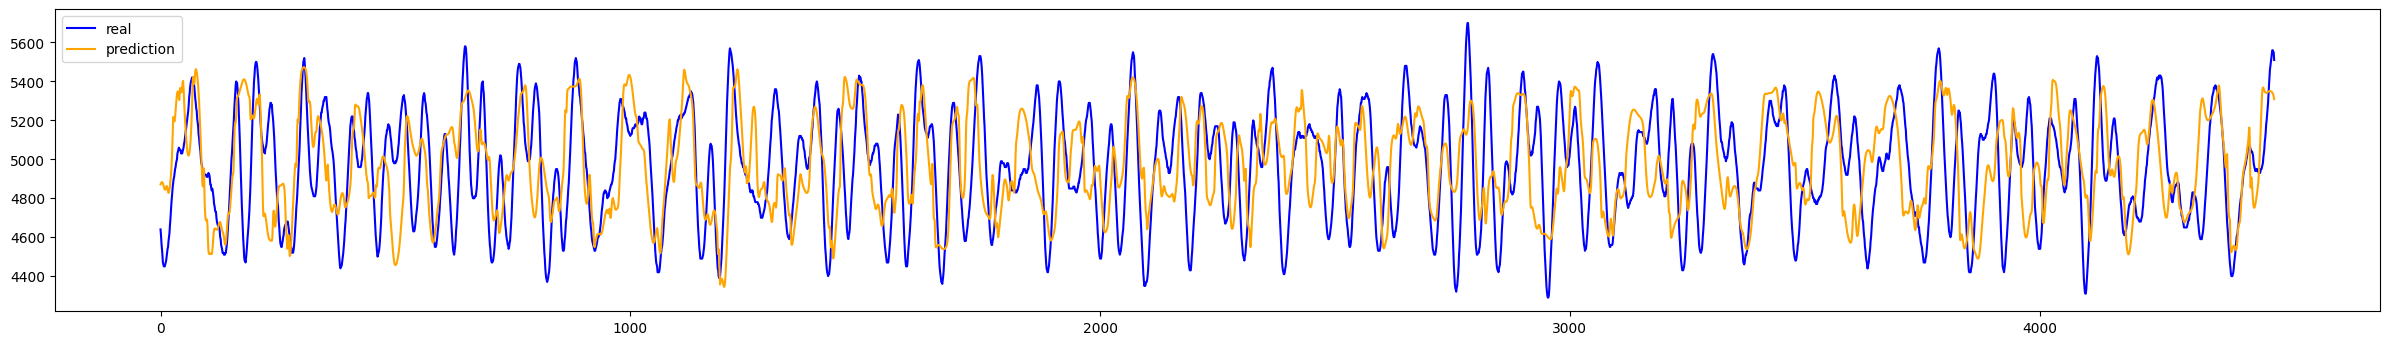

In [52]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force2500_步长30_混合注意力.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

In [53]:
RNSE(valid50_y3_Force1,N_pre50_Y3_Force1)
Acc(valid50_y3_Force1,N_pre50_Y3_Force1)

RMSE(sklearn): 0.14195392962614659
Acc: 0.9993287823527134


In [54]:
RNSE(valid50_y3_Force2,N_pre50_Y3_Force2)
Acc(valid50_y3_Force2,N_pre50_Y3_Force2)

RMSE(sklearn): 0.364079552131603
Acc: 0.8776296098495348


#### 系泊缆力联合预测（时间窗500输出；步长40）

In [55]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 8000)
heave50_model4, heave50_history4, pre_heave50_Y4 = attention_model(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 8000)
surge50_model4, surge50_history4, pre_surge50_Y4 = attention_model(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 8000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = attention_model(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 37s - loss: 0.0890 - val_loss: 0.0840
Epoch 2/30
 - 36s - loss: 0.0626 - val_loss: 0.0428
Epoch 3/30
 - 36s - loss: 0.0337 - val_loss: 0.0338
Epoch 4/30
 - 36s - loss: 0.0300 - val_loss: 0.0257
Epoch 5/30
 - 36s - loss: 0.0248 - val_loss: 0.0221
Epoch 6/30
 - 37s - loss: 0.0243 - val_loss: 0.0216
Epoch 7/30
 - 37s - loss: 0.0216 - val_loss: 0.0205
Epoch 8/30
 - 36s - loss: 0.0215 - val_loss: 0.0218
Epoch 9/30
 - 37s - loss: 0.0209 - val_loss: 0.0229
Epoch 10/30
 - 37s - loss: 0.0211 - val_loss: 0.0223
Epoch 11/30
 - 37s - loss: 0.0220 - val_loss: 0.0223
Epoch 12/30
 - 37s - loss: 0.0222 - val_loss: 0.0224
Epoch 13/30
 - 37s - loss: 0.0228 - val_loss: 0.0370
Epoch 14/30
 - 36s - loss: 0.0207 - val_loss: 0.0213
Epoch 15/30
 - 36s - loss: 0.0178 - val_loss: 0.0235
Epoch 16/30
 - 36s - loss: 0.0213 - val_loss: 0.0232
Epoch 17/30
 - 36s - loss: 0.0221 - val_loss: 0.0232
Epoch 18/30
 - 36s - loss: 0.0158 - val_loss: 0.0295
Epoch 19

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 42s - loss: 0.0715 - val_loss: 0.0616
Epoch 2/30
 - 42s - loss: 0.0648 - val_loss: 0.0579
Epoch 3/30
 - 42s - loss: 0.0680 - val_loss: 0.0486
Epoch 4/30
 - 42s - loss: 0.0635 - val_loss: 0.0467
Epoch 5/30
 - 42s - loss: 0.0547 - val_loss: 0.0559
Epoch 6/30
 - 42s - loss: 0.0567 - val_loss: 0.0496
Epoch 7/30
 - 42s - loss: 0.0546 - val_loss: 0.0497
Epoch 8/30
 - 42s - loss: 0.0513 - val_loss: 0.0628
Epoch 9/30
 - 42s - loss: 0.0484 - val_loss: 0.0564
Epoch 10/30
 - 42s - loss: 0.0462 - val_loss: 0.0771
Epoch 11/30
 - 42s - loss: 0.0373 - val_loss: 0.2102
Epoch 12/30
 - 42s - loss: 0.0461 - val_loss: 0.0825
Epoch 13/30
 - 42s - loss: 0.0397 - val_loss: 0.0990
Epoch 14/30
 - 42s - loss: 0.0323 - val_loss: 0.0995
Epoch 15/30
 - 42s - loss: 0.0367 - val_loss: 0.1018
Epoch 16/30
 - 42s - loss: 0.0328 - val_loss: 0.1161
Epoch 17/30
 - 42s - loss: 0.0417 - val_loss: 0.0824
Epoch 18/30
 - 42s - loss: 0.0284 - val_loss: 0.0947
Epoch 19

In [56]:
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 12000)
train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 12000)
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 12000)

In [57]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [58]:
pre_heave50_Y4 = heave50_model4.predict(valid_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y4 = surge50_model4.predict(valid_surge50_x4)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y4 = pitch50_model4.predict(valid_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y4.shape)
print(pre_surge50_Y4.shape)
print(pre_pitch50_Y4.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [59]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [60]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 4500, 7500, 12000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [61]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0178 - val_loss: 0.0213
Epoch 2/1000
 - 0s - loss: 0.0071 - val_loss: 0.0214
Epoch 3/1000
 - 0s - loss: 0.0048 - val_loss: 0.0211
Epoch 4/1000
 - 0s - loss: 0.0054 - val_loss: 0.0212
Epoch 5/1000
 - 0s - loss: 0.0055 - val_loss: 0.0208
Epoch 6/1000
 - 0s - loss: 0.0053 - val_loss: 0.0210
Epoch 7/1000
 - 0s - loss: 0.0054 - val_loss: 0.0209
Epoch 8/1000
 - 0s - loss: 0.0054 - val_loss: 0.0210
Epoch 9/1000
 - 0s - loss: 0.0054 - val_loss: 0.0208
Epoch 10/1000
 - 0s - loss: 0.0053 - val_loss: 0.0209
Epoch 11/1000
 - 0s - loss: 0.0053 - val_loss: 0.0208
Epoch 12/1000
 - 0s - loss: 0.0053 - val_loss: 0.0209
Epoch 13/1000
 - 0s - loss: 0.0052 - val_loss: 0.0208
Epoch 14/1000
 - 0s - loss: 0.0052 - val_loss: 0.0209
Epoch 15/1000
 - 0s - loss: 0.0052 - val_loss: 0.0209
Epoch 16/1000
 - 0s - loss: 0.0051 - val_loss: 0.0209
Epoch 17/1000
 - 0s - loss: 0.0051 - val_loss: 0.0209
Epoch 18/1000
 - 0s - loss: 0.0051 - val_lo

 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 152/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 153/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 154/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 155/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 156/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 157/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 158/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 159/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 160/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 161/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 162/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 163/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 164/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 165/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 166/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 167/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 168/1000
 - 0s - loss: 0.0044 - val_loss: 0.0213
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 301/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 302/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 303/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 304/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 305/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 306/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 307/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 308/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 309/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 310/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 311/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 312/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 313/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 314/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 315/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 316/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 317/1000
 - 0s - loss: 0.0042 - val_loss: 0.0213
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0042 - val_loss: 0.0211
Epoch 450/1000
 - 0s - loss: 0.0042 - val_loss: 0.0211
Epoch 451/1000
 - 0s - loss: 0.0042 - val_loss: 0.0211
Epoch 452/1000
 - 0s - loss: 0.0042 - val_loss: 0.0211
Epoch 453/1000
 - 0s - loss: 0.0042 - val_loss: 0.0211
Epoch 454/1000
 - 0s - loss: 0.0041 - val_loss: 0.0211
Epoch 455/1000
 - 0s - loss: 0.0041 - val_loss: 0.0211
Epoch 456/1000
 - 0s - loss: 0.0041 - val_loss: 0.0211
Epoch 457/1000
 - 0s - loss: 0.0041 - val_loss: 0.0211
Epoch 458/1000
 - 0s - loss: 0.0041 - val_loss: 0.0211
Epoch 459/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 460/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 461/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 462/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 463/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 464/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 465/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 466/1000
 - 0s - loss: 0.0041 - val_loss: 0.0212
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0041 - val_loss: 0.0217
Epoch 599/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 600/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 601/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 602/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 603/1000
 - 0s - loss: 0.0041 - val_loss: 0.0217
Epoch 604/1000
 - 0s - loss: 0.0041 - val_loss: 0.0218
Epoch 605/1000
 - 0s - loss: 0.0041 - val_loss: 0.0218
Epoch 606/1000
 - 0s - loss: 0.0041 - val_loss: 0.0219
Epoch 607/1000
 - 0s - loss: 0.0041 - val_loss: 0.0218
Epoch 608/1000
 - 0s - loss: 0.0041 - val_loss: 0.0218
Epoch 609/1000
 - 0s - loss: 0.0041 - val_loss: 0.0217
Epoch 610/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 611/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 612/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 613/1000
 - 0s - loss: 0.0041 - val_loss: 0.0216
Epoch 614/1000
 - 0s - loss: 0.0041 - val_loss: 0.0217
Epoch 615/1000
 - 0s - loss: 0.0041 - val_loss: 0.0217
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 748/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 749/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 750/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 751/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 752/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 753/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 754/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 755/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 756/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 757/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 758/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 759/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 760/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 761/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 762/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 763/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 764/1000
 - 0s - loss: 0.0040 - val_loss: 0.0215
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0039 - val_loss: 0.0211
Epoch 897/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 898/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 899/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 900/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 901/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 902/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 903/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 904/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 905/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 906/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 907/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 908/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 909/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 910/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 911/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 912/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 913/1000
 - 0s - loss: 0.0039 - val_loss: 0.0212
Epoch 914/1000
 - 0s - lo

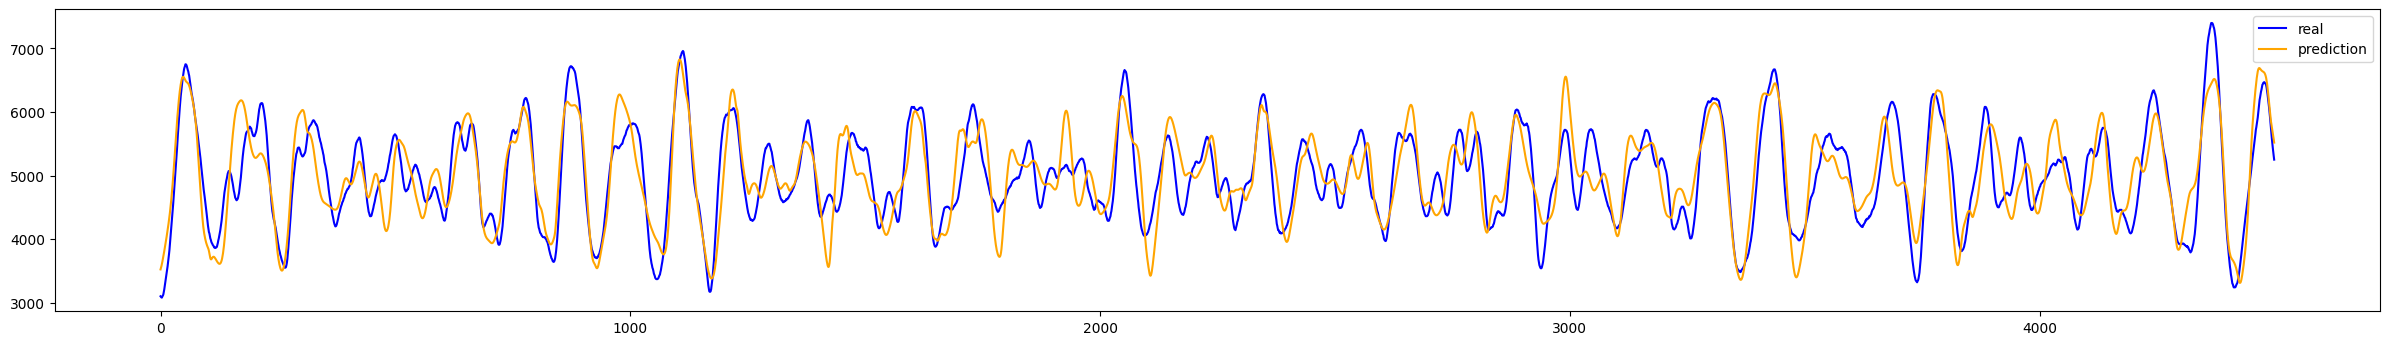

In [62]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force1500_步长40_混合注意力.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [63]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3470:,:], 4, 539)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [64]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 4500, 7500, 12000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [65]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.1010 - val_loss: 0.1234
Epoch 2/1000
 - 0s - loss: 0.0463 - val_loss: 0.1388
Epoch 3/1000
 - 0s - loss: 0.0471 - val_loss: 0.1488
Epoch 4/1000
 - 0s - loss: 0.0427 - val_loss: 0.1353
Epoch 5/1000
 - 0s - loss: 0.0411 - val_loss: 0.1404
Epoch 6/1000
 - 0s - loss: 0.0421 - val_loss: 0.1387
Epoch 7/1000
 - 0s - loss: 0.0415 - val_loss: 0.1403
Epoch 8/1000
 - 0s - loss: 0.0420 - val_loss: 0.1391
Epoch 9/1000
 - 0s - loss: 0.0414 - val_loss: 0.1396
Epoch 10/1000
 - 0s - loss: 0.0418 - val_loss: 0.1394
Epoch 11/1000
 - 0s - loss: 0.0413 - val_loss: 0.1397
Epoch 12/1000
 - 0s - loss: 0.0415 - val_loss: 0.1395
Epoch 13/1000
 - 0s - loss: 0.0412 - val_loss: 0.1398
Epoch 14/1000
 - 1s - loss: 0.0413 - val_loss: 0.1396
Epoch 15/1000
 - 0s - loss: 0.0410 - val_loss: 0.1398
Epoch 16/1000
 - 0s - loss: 0.0411 - val_loss: 0.1397
Epoch 17/1000
 - 0s - loss: 0.0409 - val_loss: 0.1399
Epoch 18/1000
 - 0s - loss: 0.0409 - val_lo

 - 0s - loss: 0.0366 - val_loss: 0.1400
Epoch 152/1000
 - 0s - loss: 0.0366 - val_loss: 0.1400
Epoch 153/1000
 - 0s - loss: 0.0366 - val_loss: 0.1400
Epoch 154/1000
 - 0s - loss: 0.0366 - val_loss: 0.1400
Epoch 155/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 156/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 157/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 158/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 159/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 160/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 161/1000
 - 0s - loss: 0.0365 - val_loss: 0.1400
Epoch 162/1000
 - 0s - loss: 0.0364 - val_loss: 0.1400
Epoch 163/1000
 - 0s - loss: 0.0364 - val_loss: 0.1400
Epoch 164/1000
 - 0s - loss: 0.0364 - val_loss: 0.1399
Epoch 165/1000
 - 0s - loss: 0.0364 - val_loss: 0.1399
Epoch 166/1000
 - 0s - loss: 0.0364 - val_loss: 0.1399
Epoch 167/1000
 - 0s - loss: 0.0364 - val_loss: 0.1399
Epoch 168/1000
 - 0s - loss: 0.0364 - val_loss: 0.1398
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0341 - val_loss: 0.1362
Epoch 301/1000
 - 0s - loss: 0.0341 - val_loss: 0.1362
Epoch 302/1000
 - 0s - loss: 0.0340 - val_loss: 0.1361
Epoch 303/1000
 - 0s - loss: 0.0340 - val_loss: 0.1361
Epoch 304/1000
 - 0s - loss: 0.0340 - val_loss: 0.1361
Epoch 305/1000
 - 0s - loss: 0.0340 - val_loss: 0.1361
Epoch 306/1000
 - 0s - loss: 0.0340 - val_loss: 0.1360
Epoch 307/1000
 - 0s - loss: 0.0340 - val_loss: 0.1360
Epoch 308/1000
 - 0s - loss: 0.0340 - val_loss: 0.1360
Epoch 309/1000
 - 0s - loss: 0.0340 - val_loss: 0.1360
Epoch 310/1000
 - 0s - loss: 0.0340 - val_loss: 0.1359
Epoch 311/1000
 - 0s - loss: 0.0340 - val_loss: 0.1359
Epoch 312/1000
 - 0s - loss: 0.0339 - val_loss: 0.1359
Epoch 313/1000
 - 0s - loss: 0.0339 - val_loss: 0.1359
Epoch 314/1000
 - 0s - loss: 0.0339 - val_loss: 0.1358
Epoch 315/1000
 - 0s - loss: 0.0339 - val_loss: 0.1358
Epoch 316/1000
 - 0s - loss: 0.0339 - val_loss: 0.1358
Epoch 317/1000
 - 0s - loss: 0.0339 - val_loss: 0.1358
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0327 - val_loss: 0.1390
Epoch 450/1000
 - 0s - loss: 0.0327 - val_loss: 0.1391
Epoch 451/1000
 - 0s - loss: 0.0327 - val_loss: 0.1391
Epoch 452/1000
 - 0s - loss: 0.0326 - val_loss: 0.1392
Epoch 453/1000
 - 0s - loss: 0.0326 - val_loss: 0.1392
Epoch 454/1000
 - 0s - loss: 0.0326 - val_loss: 0.1392
Epoch 455/1000
 - 0s - loss: 0.0326 - val_loss: 0.1392
Epoch 456/1000
 - 0s - loss: 0.0326 - val_loss: 0.1393
Epoch 457/1000
 - 0s - loss: 0.0326 - val_loss: 0.1393
Epoch 458/1000
 - 0s - loss: 0.0326 - val_loss: 0.1393
Epoch 459/1000
 - 0s - loss: 0.0326 - val_loss: 0.1394
Epoch 460/1000
 - 0s - loss: 0.0326 - val_loss: 0.1394
Epoch 461/1000
 - 0s - loss: 0.0326 - val_loss: 0.1394
Epoch 462/1000
 - 0s - loss: 0.0326 - val_loss: 0.1394
Epoch 463/1000
 - 0s - loss: 0.0326 - val_loss: 0.1395
Epoch 464/1000
 - 0s - loss: 0.0326 - val_loss: 0.1395
Epoch 465/1000
 - 0s - loss: 0.0326 - val_loss: 0.1395
Epoch 466/1000
 - 0s - loss: 0.0326 - val_loss: 0.1395
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 599/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 600/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 601/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 602/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 603/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 604/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 605/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 606/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 607/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 608/1000
 - 0s - loss: 0.0322 - val_loss: 0.1414
Epoch 609/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 610/1000
 - 0s - loss: 0.0322 - val_loss: 0.1414
Epoch 611/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 612/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 613/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 614/1000
 - 0s - loss: 0.0322 - val_loss: 0.1413
Epoch 615/1000
 - 0s - loss: 0.0322 - val_loss: 0.1414
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 748/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 749/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 750/1000
 - 0s - loss: 0.0319 - val_loss: 0.1420
Epoch 751/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 752/1000
 - 0s - loss: 0.0319 - val_loss: 0.1420
Epoch 753/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 754/1000
 - 0s - loss: 0.0319 - val_loss: 0.1420
Epoch 755/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 756/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 757/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 758/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 759/1000
 - 0s - loss: 0.0319 - val_loss: 0.1418
Epoch 760/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 761/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 762/1000
 - 0s - loss: 0.0319 - val_loss: 0.1420
Epoch 763/1000
 - 0s - loss: 0.0319 - val_loss: 0.1419
Epoch 764/1000
 - 0s - loss: 0.0319 - val_loss: 0.1420
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0315 - val_loss: 0.1420
Epoch 897/1000
 - 0s - loss: 0.0314 - val_loss: 0.1439
Epoch 898/1000
 - 0s - loss: 0.0315 - val_loss: 0.1420
Epoch 899/1000
 - 0s - loss: 0.0314 - val_loss: 0.1439
Epoch 900/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 901/1000
 - 0s - loss: 0.0314 - val_loss: 0.1439
Epoch 902/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 903/1000
 - 0s - loss: 0.0314 - val_loss: 0.1440
Epoch 904/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 905/1000
 - 0s - loss: 0.0314 - val_loss: 0.1440
Epoch 906/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 907/1000
 - 0s - loss: 0.0314 - val_loss: 0.1440
Epoch 908/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 909/1000
 - 0s - loss: 0.0314 - val_loss: 0.1441
Epoch 910/1000
 - 0s - loss: 0.0315 - val_loss: 0.1421
Epoch 911/1000
 - 0s - loss: 0.0313 - val_loss: 0.1441
Epoch 912/1000
 - 0s - loss: 0.0315 - val_loss: 0.1420
Epoch 913/1000
 - 0s - loss: 0.0313 - val_loss: 0.1442
Epoch 914/1000
 - 0s - lo

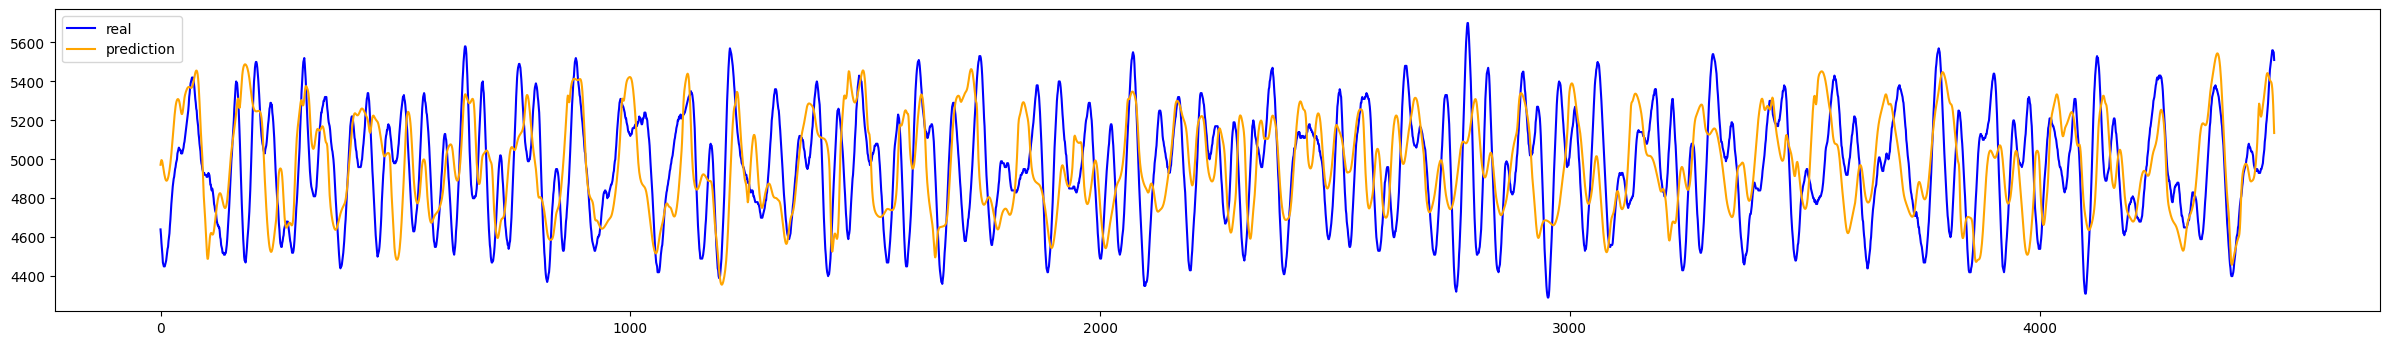

In [66]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force2500_步长40_混合注意力.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')

In [67]:
RNSE(valid50_y4_Force1,N_pre50_Y4_Force1)
Acc(valid50_y4_Force1,N_pre50_Y4_Force1)

RMSE(sklearn): 0.1445038421928082
Acc: 0.9543681247877065


In [68]:
RNSE(valid50_y4_Force2,N_pre50_Y4_Force2)
Acc(valid50_y4_Force2,N_pre50_Y4_Force2)

RMSE(sklearn): 0.37769023527542533
Acc: 0.8745639210098893
